In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from functools import reduce
import numpy as np
import pandas as pd
import re
import gc
import datetime as _dt
import pyarrow.parquet as pq
from collections import defaultdict
from dateutil.relativedelta import relativedelta
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.metrics import precision_recall_curve, auc
from deap import base, creator, tools, algorithms

In [19]:
df = pd.read_csv('features_v3.csv')
df.head()

,user,email_external_ratio,email_suspicious_content_ratio,email_bcc_email_ratio,email_external_email_with_attachment_ratio,email_after_hours_or_weekend_ratio,email_max_zscore_emails,email_avg_emails_per_week,email_avg_size_sent_email,email_zscore_last_month,...,http_download_ratio,http_off_hours_ratio,http_last_month_zscore,http_max_zscore_activity,http_sus_domain_ratio,http_unique_domains,http_job_search_score,users_post_departure_activity,users_pre_departure_ratio,users_activity_not_main_pc_ratio
0,AAB0162,0.307374,0.014940,0.0,0.051176,0.000000,0.0,42.513514,1.994349e+05,-0.871931,...,0.0,0.0000,0.0,0.0,0.0318,126,0.0699,0.0,0.000000,0.0
1,AAB0398,0.383626,0.003674,0.0,0.118079,0.056416,0.0,51.500000,3.568791e+05,-0.095175,...,0.0,0.0474,0.0,0.0,0.0308,248,0.0133,0.0,0.000000,0.0
2,AAC0610,0.363118,0.009506,0.0,0.132129,0.000000,0.0,14.216216,8.273392e+05,0.315768,...,0.0,0.0096,0.0,0.0,0.1031,200,0.0189,0.0,0.001404,0.0
3,AAC0668,0.350562,0.007705,0.0,0.070305,0.000000,0.0,42.094595,4.068177e+05,0.439913,...,0.0,0.0000,0.0,0.0,0.0342,175,0.0548,0.0,0.000000,0.0
4,AAC3270,0.258721,0.000000,0.0,0.139535,0.000000,0.0,4.648649,1.333953e+06,0.901975,...,0.0,0.0000,0.0,0.0,0.0000,55,0.0045,0.0,0.000000,0.0


In [20]:
df.columns

Index(['user', 'email_external_ratio', 'email_suspicious_content_ratio',
       'email_bcc_email_ratio', 'email_external_email_with_attachment_ratio',
       'email_after_hours_or_weekend_ratio', 'email_max_zscore_emails',
       'email_avg_emails_per_week', 'email_avg_size_sent_email',
       'email_zscore_last_month', 'file_copy_ratio', 'file_write_ratio',
       'file_delete_ratio', 'file_copy_to_removable_ratio',
       'file_from_removable_ratio', 'file_events_per_file',
       'file_off_hours_ratio', 'file_suspicious_file_content_ratio',
       'file_open_then_copy_ratio', 'file_copy_then_delete_ratio',
       'file_max_zscore_file_activity', 'file_zscore_last_month',
       'logon_average_session_duration', 'logon_session_duration_variability',
       'logon_ratio_short_sessions', 'logon_used_multi_pc_simultaneously',
       'logon_unclosed_session_ratio', 'logon_after_hours_logon_ratio',
       'logon_max_zscore_logon', 'logon_max_zscore_logon_after_hours',
       'logon_zscore

In [21]:
l = pd.read_csv('cert_dataset/insiders/insiders.csv')
insiders = l[l['dataset']==6.2]['user']
insiders

186    ACM2278
187    CMP2946
188    PLJ1771
189    CDE1846
190    MBG3183
Name: user, dtype: object

In [22]:
df['is_insider'] = df['user'].isin(insiders).astype(int)
df['is_insider'].value_counts()

is_insider
0    3995
1       5
Name: count, dtype: int64

In [23]:
X = df.drop(columns=['user','is_insider','file_open_then_copy_ratio', 'file_copy_then_delete_ratio'])

s_scaler = StandardScaler()

m_scaler = MinMaxScaler()

X_scaled_s = s_scaler.fit_transform(X)

X_scaled_m = m_scaler.fit_transform(X)

model = IsolationForest(
    n_estimators=50000,
    max_samples=2000,
    max_features=1.0,
    random_state=42
)

model.fit(X_scaled_s)

IsolationForest(max_samples=2000, n_estimators=50000, random_state=42)

In [24]:
df['anomaly_score'] = -model.score_samples(X_scaled_s)

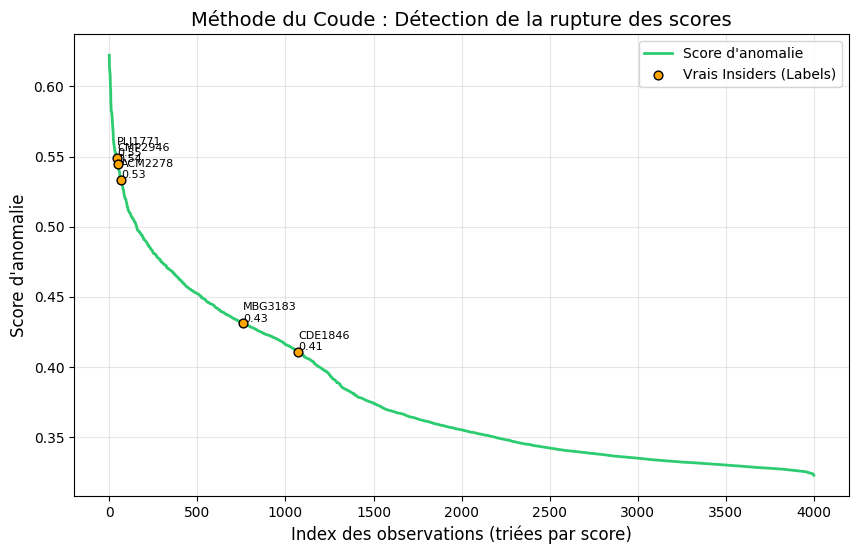

In [25]:
sorted_indices = np.argsort(df['anomaly_score'].values)[::-1]

sorted_scores = df['anomaly_score'].values[sorted_indices]

sorted_insiders = df['is_insider'].values[sorted_indices]

sorted_users = df['user'].values[sorted_indices]

insider_plot_indices = np.where(sorted_insiders == 1)[0]

plt.figure(figsize=(10, 6))

plt.plot(range(len(sorted_scores)), sorted_scores, label='Score d\'anomalie', color='#2ecc71', linewidth=2)

plt.scatter(insider_plot_indices, sorted_scores[insider_plot_indices], 
            color='orange', label='Vrais Insiders (Labels)', zorder=5, s=40, edgecolors='black')

for i in insider_plot_indices:
    user_id = sorted_users[i]
    score = sorted_scores[i]
    
    plt.text(i, score,
             f"{user_id}\n{score:.2f}",
             fontsize=8,
             ha='left',
             va='bottom')
    
plt.title("Méthode du Coude : Détection de la rupture des scores", fontsize=14)

plt.xlabel("Index des observations (triées par score)", fontsize=12)

plt.ylabel("Score d'anomalie", fontsize=12)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Genetic Algorithm

In [29]:
df = pd.read_csv('features_v3.csv')

X = df.drop(columns='user')

In [30]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [31]:
N_FEATURES = len(X.columns)
INSIDERS =  l[l['dataset']==6.2]['user']
K = 25

In [33]:
def fitness_function(individual):

    selected = [col for col, bit in zip(X.columns, individual) if bit == 1]

    if len(selected) == 0:
        return (0.0,)
    
    X_selected = X_scaled[selected]

    clf = IsolationForest(
        n_estimators=1000,
        random_state=42,
        max_samples=2000,
        max_features=1.0,
    )

    clf.fit(X_selected)
    scores = -clf.score_samples(X_selected)
    df_scores = pd.DataFrame({'user':df['user'],'score':scores})
    df_scores = df_scores.sort_values('score',ascending=False)
    df_scores['rank'] = range(1,len(df_scores)+1)

    total_users = len(df_scores)
    insider_ranks = df_scores[df_scores['user'].isin(INSIDERS)]['rank'].values

    if len(insider_ranks) == 0:
        return (0.0,)
    
    mean_rank = np.mean(insider_ranks) / total_users

    top_k_hits = np.sum(insider_ranks <= K) / len(INSIDERS)

    alpha = 0.6

    fitness = alpha * (1-mean_rank) + (1 - alpha) * top_k_hits

    return (fitness,)

In [34]:
creator.create('FitnessMax', base.Fitness, weights=(1.0,))
creator.create('Individual', list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

toolbox.register('attr_bool',np.random.randint,0,2)
toolbox.register('individual',tools.initRepeat,
                 creator.Individual, toolbox.attr_bool, n=N_FEATURES)
toolbox.register('population',tools.initRepeat,
                 list,toolbox.individual)
toolbox.register('evaluate',fitness_function)

toolbox.register('mate', tools.cxTwoPoint)
toolbox.register('mutate',tools.mutFlipBit,indpb=0.05)
toolbox.register('select',tools.selTournament,tournsize=3)

In [35]:
def run_ga(pop_size=100,n_gen=20):

    pop = toolbox.population(n=pop_size)
    hof = tools.HallOfFame(1)

    stats = tools.Statistics(lambda ind : ind.fitness.values)
    stats.register('max', np.max)
    stats.register('mean',np.mean)

    algorithms.eaSimple(
        pop, toolbox,
        cxpb=0.7, mutpb=0.2,
        ngen=n_gen,
        stats=stats,
        halloffame=hof,
        verbose=True
    )

    return hof[0]

best = run_ga()

best_features = [col for col, bit in zip(X.columns, best) if bit == 1]
print(f"Features sélectionnées ({len(best_features)}) :", best_features)
print("Fitness :", best.fitness.values[0])

gen	nevals	max    	mean    
0  	100   	0.77922	0.576583
1  	70    	0.77781	0.615648
2  	69    	0.80178	0.661422
3  	74    	0.81021	0.694278
4  	77    	0.81378	0.705961
5  	74    	0.81471	0.74702 
6  	70    	0.81471	0.766943
7  	77    	0.81936	0.786329
8  	66    	0.81819	0.786711
9  	66    	0.81951	0.797261
10 	81    	0.82278	0.802141
11 	78    	0.82143	0.803109
12 	72    	0.82314	0.807298
13 	80    	0.82473	0.813109
14 	77    	0.82647	0.811305
15 	68    	0.83061	0.814865
16 	79    	0.83076	0.812234
17 	77    	0.83166	0.819332
18 	73    	0.83118	0.817649
19 	70    	0.83325	0.819064
20 	82    	0.83325	0.821004
Features sélectionnées (11) : ['email_max_zscore_emails', 'email_zscore_last_month', 'file_copy_ratio', 'file_delete_ratio', 'file_copy_to_removable_ratio', 'file_from_removable_ratio', 'file_max_zscore_file_activity', 'device_max_zscore_device_week', 'device_ratio_device_conn_after_hours', 'device_zscore_last_month', 'http_job_search_score']
Fitness : 0.8332499999999999


In [36]:
X_with_best_features = X_scaled[best_features]

model = IsolationForest(
    n_estimators=100000,
    max_samples=4000,
    max_features=1.0,
    random_state=42
)

model.fit(X_with_best_features)

IsolationForest(max_samples=4000, n_estimators=100000, random_state=42)

In [37]:
df['anomaly_score_best_features'] = -model.score_samples(X_with_best_features)

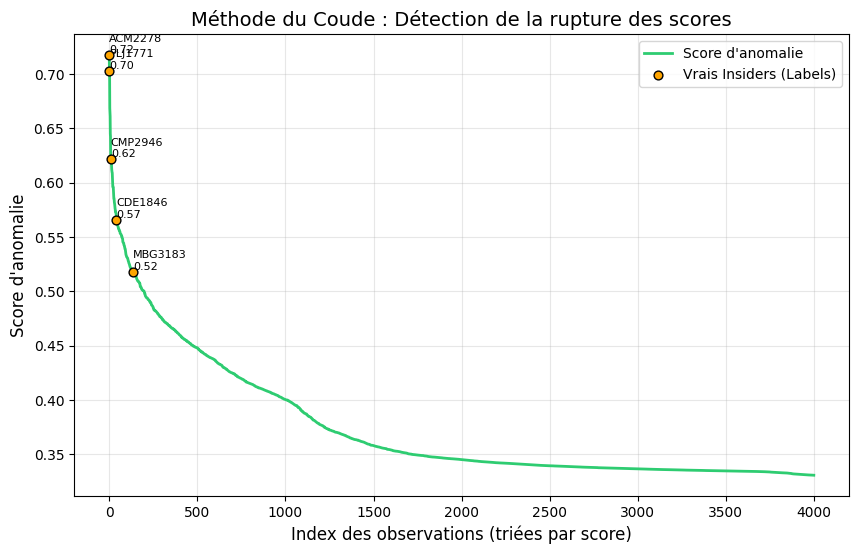

In [38]:
df['is_insider'] = df['user'].isin(insiders).astype(int)
df['is_insider'].value_counts()

sorted_indices = np.argsort(df['anomaly_score_best_features'].values)[::-1]

sorted_scores = df['anomaly_score_best_features'].values[sorted_indices]

sorted_insiders = df['is_insider'].values[sorted_indices]

sorted_users = df['user'].values[sorted_indices]

insider_plot_indices = np.where(sorted_insiders == 1)[0]

plt.figure(figsize=(10, 6))

plt.plot(range(len(sorted_scores)), sorted_scores, label='Score d\'anomalie', color='#2ecc71', linewidth=2)

plt.scatter(insider_plot_indices, sorted_scores[insider_plot_indices], 
            color='orange', label='Vrais Insiders (Labels)', zorder=5, s=40, edgecolors='black')

for i in insider_plot_indices:
    user_id = sorted_users[i]
    score = sorted_scores[i]
    
    plt.text(i, score,
             f"{user_id}\n{score:.2f}",
             fontsize=8,
             ha='left',
             va='bottom')
    
plt.title("Méthode du Coude : Détection de la rupture des scores", fontsize=14)

plt.xlabel("Index des observations (triées par score)", fontsize=12)

plt.ylabel("Score d'anomalie", fontsize=12)

plt.legend()

plt.grid(alpha=0.3)

plt.show()